## Settings and imports

In [1]:
import sys
sys.path.insert(0, '../src/')
from data_utils import *
from train_and_evaluate import *
from model import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

PREPROCESSING_METHOD = config["preprocessing_method"] # normalization / logarithm
HOW_MANY_OUTER_TO_REMOVE = config["how_many_outer_to_remove"]
ELEMENTS_TO_KEEP = config["elements_to_keep"]
MULTIPLICATION_WEIGHTS = config["multiplication_weights"]
DROPOUT_PROB = config["dropout_prob"]

DATA_PATH = config["data_path"]
RESULTS_PATH = config["results_path"]
FIGURES_PATH = config["figures_path"]
MODELS_PATH = config["models_path"]

## Loading the data

In [3]:
inDKs_df, inks_df, inds_df = load_training_data(DATA_PATH)

In [4]:
inDKs_df

,Na_a,Mg_a,Al_a,S_a,K_a,Ti_a,V_a,Cr_a,Mn_a,Fe_a,...,Co_i,Cu_i,Zn_i,Sr_i,Cd_i,Sn_i,Ba_i,Hg_i,Pb_i,name_i
0,114591.32222,7298.00000,21644.22222,6160.45556,238193.08889,51.55556,5.11111,5.44444,2081.02222,187877.22222,...,4.33333,118.55556,261.00000,7.11111,8.48148,4.88889,1.00000,24.21852,29.88889,102vA.i_0
1,102675.43333,7124.66667,15953.33333,6766.45556,248239.42222,63.88889,4.11111,7.66667,2126.80000,178843.44444,...,4.44444,132.00000,321.11111,7.44444,10.72593,3.55556,1.00000,35.53704,32.22222,102vA.i_1
2,103476.76667,7052.44444,18599.00000,5225.56667,199796.08889,23.11111,4.77778,13.33333,2014.35556,167346.00000,...,4.44444,118.11111,254.22222,6.00000,12.82963,5.77778,1.00000,26.48889,33.33333,102vA.i_2
3,102761.54444,7233.22222,15962.22222,5895.45556,205310.53333,57.55556,3.66667,16.66667,2034.46667,163188.55556,...,7.88889,124.00000,185.55556,4.88889,13.60741,2.11111,1.00000,3.98148,32.55556,102vA.i_3
4,97071.76667,6653.55556,16507.66667,5777.45556,235162.75556,86.22222,6.00000,8.77778,2012.57778,159342.44444,...,5.00000,120.44444,210.66667,6.33333,17.61481,2.55556,1.00000,13.66296,29.44444,102vA.i_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2485,15103.22222,11375.02222,815.44444,27411.60000,49378.27778,37.22222,2.44444,35.48889,1397.81111,770014.74444,...,3.11111,1664.88889,17.55556,122.77778,1.00000,3.22222,9.55556,9.27407,1.77778,INK.i_5
2486,17368.55556,8502.91111,1614.00000,26236.93333,46796.94444,31.11111,4.33333,46.04444,1378.47778,761933.07778,...,3.11111,1692.33333,13.55556,102.66667,1.00000,3.33333,29.11111,8.18519,6.55556,INK.i_6
2487,17242.55556,7506.35556,1042.55556,26964.26667,50308.05556,17.00000,2.66667,32.12593,1446.47778,755794.52222,...,3.00000,1765.11111,14.66667,132.00000,1.00000,2.55556,9.44444,11.17037,3.55556,INK.i_7
2488,15811.00000,7594.57778,1093.22222,26598.71111,49603.38889,25.11111,3.33333,22.90370,1404.14444,748113.85556,...,5.22222,1719.33333,20.00000,84.00000,1.00000,3.11111,17.33333,8.17037,7.11111,INK.i_8


## Preprocessing

### Keeping track of the records from the same sample

We will keep this info in 'Sample_id' and 'name' columns.

In [5]:
inDKs_df = create_sample_id(inDKs_df)

1. Let's remove 'outer' samples:

In [6]:
inDKs_df = remove_outer_samples(inDKs_df, HOW_MANY_OUTER_TO_REMOVE)

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 10. We will also use only 10 numbers as input.

In [7]:
inDKs_df = delete_elements(inDKs_df, ELEMENTS_TO_KEEP)

3. Let's remove rows with missing values if there are any.

In [8]:
inDKs_df = remove_missing_data(inDKs_df)

4. Let's set negative numbers to zeros. (First, check if there are any.)

In [9]:
inDKs_df = set_negative_to_zero(inDKs_df, ELEMENTS_TO_KEEP)

5. Let's multiply the values by weights.

In [10]:
inDKs_df = multiply_by_weights(inDKs_df, ELEMENTS_TO_KEEP, weights=MULTIPLICATION_WEIGHTS)

6. Normalize with respect to Fe and remove Fe.

In [11]:
# inDKs_df = normalize_to_Fe(inDKs_df, ELEMENTS_TO_KEEP)

### Train test split, datasets, dataloaders

In [12]:
X_y_train, X_y_val, X_y_test = create_partition(inDKs_df)

### Creating features and labels matrices

In [13]:
X_train, y_train, X_val, y_val, X_test, y_test, train_order, val_order, test_order = prepare_data_for_training(
                                                                                                                X_y_train, 
                                                                                                                X_y_val, 
                                                                                                                X_y_test, 
                                                                                                                ELEMENTS_TO_KEEP)

### Normalization / taking logarithm

In [14]:
X_train, y_train = transform_data(X_train, y_train, 'logarithm')
X_val, y_val = transform_data(X_val, y_val, 'logarithm')
X_test, y_test = transform_data(X_test, y_test, 'logarithm')

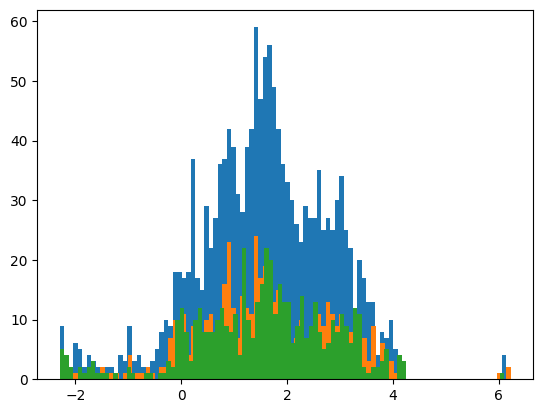

In [15]:
dim = 3
plt.hist(X_train[:,dim], bins=100);
plt.hist(X_test[:,dim], bins=100);
plt.hist(X_val[:,dim], bins=100);

### Converting to tensors

In [16]:
device = get_device()

Using cuda device


In [17]:
X_train, y_train = data_to_device(X_train, y_train, device)
X_val, y_val = data_to_device(X_val, y_val, device)
X_test, y_test = data_to_device(X_test, y_test, device)

### Dataset

In [18]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [19]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Neural network

In [20]:
model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): Dropout(p=0.1, inplace=False)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=256, bias=True)
    (5): Dropout(p=0.1, inplace=False)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=1024, bias=True)
    (9): Dropout(p=0.1, inplace=False)
    (10): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=1024, out_features=256, bias=True)
    (13): Dropout(p=0.1, inplace=False)
    (14): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU()
    (16): Linear(in_features=256, out_features=64, bias=True)
    (17): Dropout(p=0.1, inplace=False)
    (18): BatchNorm1d(64, eps=1e-05

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

In [21]:
weights = torch.tensor([1/INPUT_SIZE]*INPUT_SIZE).unsqueeze(1).to(device)
loss_fn = CustomLoss(weights=weights)
model, train_losses, val_losses = train_model(model=model,
                                              train_loader=train_loader,
                                              val_loader=val_loader,
                                              epochs=5000,
                                              loss_fn=loss_fn)

EPOCH 1:
LOSS train 4.666157086690267 test 4.5884152227137465
EPOCH 2:
LOSS train 4.2997790018717446 test 4.024888936534943
EPOCH 3:
LOSS train 3.919907283782959 test 3.426749616502279
EPOCH 4:
LOSS train 3.4793540318806966 test 2.9846060156343452
EPOCH 5:
LOSS train 3.003653573989868 test 2.62143160911449
EPOCH 6:
LOSS train 2.5494654496510822 test 2.144934270515978
EPOCH 7:
LOSS train 2.1208809773127237 test 1.7313166964484985
EPOCH 8:
LOSS train 1.7761671781539916 test 1.598612735190066
EPOCH 9:
LOSS train 1.5178832848866781 test 1.4089219667107227
EPOCH 10:
LOSS train 1.3362779140472412 test 1.1784612358693618
EPOCH 11:
LOSS train 1.1936105966567994 test 1.105401133318024
EPOCH 12:
LOSS train 1.0903693834940593 test 1.0066523809868648
EPOCH 13:
LOSS train 0.9867128690083822 test 0.8688951689435775
EPOCH 14:
LOSS train 0.9057329972585042 test 0.819023569006039
EPOCH 15:
LOSS train 0.8541919112205505 test 0.7807942812581617
EPOCH 16:
LOSS train 0.8012032032012939 test 0.7667688049346

KeyboardInterrupt: 

### Loss visualisation

In [45]:
#%matplotlib widget

In [27]:
#visualise_losses(train_losses, val_losses)

## Loading pretrained model

In [22]:
model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
model.load_state_dict(torch.load(MODELS_PATH))

/tmp/ipykernel_9156/2341782259.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODELS_PATH))


<All keys matched successfully>

## Prediction on test set

In [23]:
labels, outputs, difference, mean_loss = evaluate_on_test_set(model=model, 
                                                              test_loader=test_loader, 
                                                              loss_fn=loss_fn)

Consecutive inks from test set are in labels tensor (498 examples, 10 elements/coordinates):

In [27]:
labels

tensor([[ 3.8680,  2.0324, -1.8046,  ...,  4.8597, 11.1846,  4.9238],
        [ 4.6584,  2.3974, -0.9194,  ...,  7.1934, 11.0806,  4.6677],
        [ 3.1933,  2.0893, -2.3112,  ...,  4.2102, 10.7668,  4.2131],
        ...,
        [ 3.7895,  2.1499, -2.6429,  ...,  5.1586, 10.3751,  4.7508],
        [ 5.4275,  3.5121, -1.0072,  ...,  6.6777, 12.4322,  5.9789],
        [ 4.0341,  2.5511, -2.1872,  ...,  5.4481, 10.1772,  4.3534]],
       device='cuda:0')

Predictions are in out tensor (498 examples, 10 elements/coordinates):

In [28]:
outputs

tensor([[ 3.6408,  2.1631, -1.7982,  ...,  4.8085, 11.2371,  4.7656],
        [ 4.5595,  2.3560, -0.9571,  ...,  7.1602, 11.0215,  4.7227],
        [ 3.2905,  2.3947, -3.0946,  ...,  4.1251, 10.9164,  4.5920],
        ...,
        [ 3.8200,  2.2752, -1.4143,  ...,  5.2794, 10.3133,  4.6790],
        [ 5.3195,  3.5565, -0.8774,  ...,  6.6057, 12.3332,  6.0015],
        [ 4.1554,  1.8856, -2.5341,  ...,  5.3885, 10.2799,  4.6835]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (labels) and prediction (outputs) are stored in difference tensor (498 examples, 10 elements/coordinates):

In [29]:
difference

tensor([[0.2273, 0.1307, 0.0065,  ..., 0.0512, 0.0524, 0.1582],
        [0.0989, 0.0414, 0.0377,  ..., 0.0332, 0.0591, 0.0550],
        [0.0972, 0.3054, 0.7834,  ..., 0.0850, 0.1497, 0.3789],
        ...,
        [0.0305, 0.1253, 1.2286,  ..., 0.1209, 0.0618, 0.0718],
        [0.1080, 0.0445, 0.1298,  ..., 0.0720, 0.0990, 0.0227],
        [0.1214, 0.6655, 0.3470,  ..., 0.0596, 0.1027, 0.3302]],
       device='cuda:0', grad_fn=<CatBackward0>)

Mean loss:

In [30]:
mean_loss

0.1898058955613748

In [31]:
torch.mean(difference, axis=0)  # 10 elements, new data

tensor([0.1364, 0.1907, 0.3598, 0.1390, 0.2053, 0.1704, 0.2070, 0.1809, 0.1565,
        0.1520], device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb, Fe, Mg

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

## Saving the model

In [78]:
outer_removed = 'outer_removed' if remove_outer else 'outer_not_removed'

elements = '_'.join(elements_to_keep)
settings_str = '_' + preprocessing_method + '_' + \
                outer_removed + '_' + str(how_many_outer_to_remove) + \
                '_' + elements + '_'

import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

#torch.save(model.state_dict(), '/'.join(models_path.split('/')[:-1]) + '/model_regression' + settings_str + now)

### Visualisations

In [41]:
dim_nr = 9
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

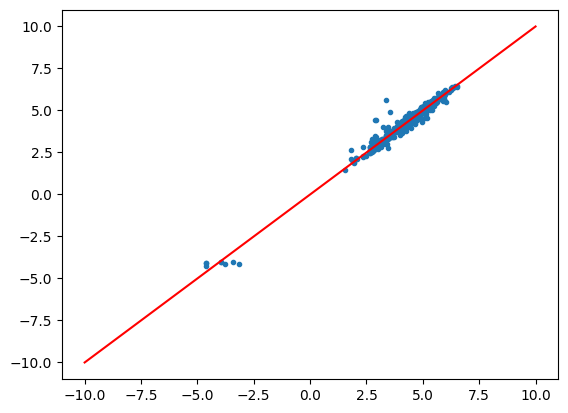

In [42]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [40]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds]

In [42]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [99]:
mean_df = train_val_df[['Sample_id']].copy()

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
mean_df.drop_duplicates('Sample_id', inplace=True)

mean_df['Sample_id'] = mean_df['Sample_id'].astype(str)
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [100]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [101]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [102]:
y_test_df['Closest'] = closest

In [103]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

481

In [104]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / y_test_df.shape[0]

0.9658634538152611

#### Now let's check if it works for the neural network's output.

In [105]:
model.eval()
outputs = model(X_test)

In [106]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df['Real sample_id'] = outputs_df['Real sample_id'].astype(str)
outputs_df.reset_index(drop=True, inplace=True)

In [107]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [108]:
len(closest)

498

In [109]:
outputs_df['Closest'] = closest

In [110]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

449

In [111]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest) #new data

0.9016064257028112

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from seaborn import heatmap

In [60]:
acc = np.round(100*outputs_df[outputs_df['Real sample_id'] == outputs_df['Closest']].shape[0] / len(closest), 1)
print('Accuracy: '+str(acc)+'%.') # new data

Accuracy: 90.2%.


In [61]:
normalization_in_conf_mat = None

conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'], 
                            normalize=normalization_in_conf_mat)

tp_and_fn = conf_mat.sum(1)
tp_and_fp = conf_mat.sum(0)
tp = conf_mat.diagonal()

precision = tp / tp_and_fp
recall = tp / tp_and_fn

print('Precision: ' + str(np.nanmean(precision)))
print('Recall: ' + str(np.nanmean(recall)))

Precision: 0.9254805591961556
Recall: 0.9107142857142857


/tmp/ipykernel_27015/2917754103.py:10: RuntimeWarning: invalid value encountered in divide
  precision = tp / tp_and_fp
/tmp/ipykernel_27015/2917754103.py:11: RuntimeWarning: invalid value encountered in divide
  recall = tp / tp_and_fn


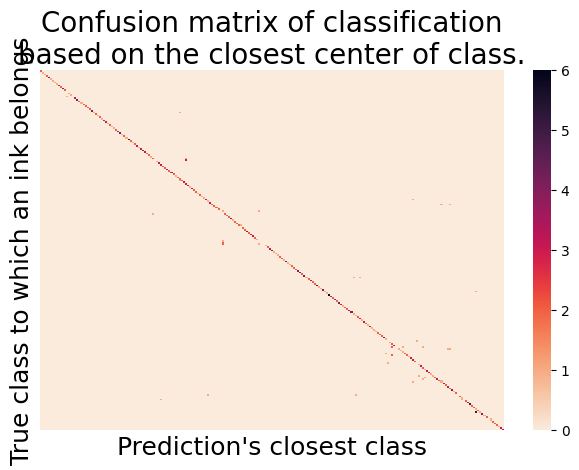

In [62]:
normalization_in_conf_mat = None
scores = {
            'pred': 'Precision',
            'true': 'Recall',
            None: 'Confusion matrix'
            }

conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'], 
                            normalize=normalization_in_conf_mat)

heatmap(conf_mat, cmap=sns.cm.rocket_r, xticklabels=False, yticklabels=False)
plt.ylabel('True class to which an ink belongs', size=18)
plt.xlabel("Prediction's closest class", size=18)
plt.rcParams['figure.figsize'] = [15, 10]
plt.title(scores[normalization_in_conf_mat] + ' of classification based on the closest center of class.', 
          size=20, 
          wrap=True)

plt.tight_layout()
#plt.savefig('../figures/heatmap_' + scores[normalization_in_conf_mat] + '.png')

## Quality of prediction: confidence intervals

In [83]:
model.eval()
outputs = model(X_test)

In [84]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds]

In [120]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [121]:
min_max_df = all_data_df[['Sample_id']].copy()

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    
min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

In [122]:
mean_sd_df = all_data_df[['Sample_id']].copy()

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_5665/1151196045.py:8: FutureWarning: The provided callable <function std at 0x757d01aedc60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
/tmp/ipykernel_5665/1151196045.py:8: FutureWarning: The provided callable <function std at 0x757d01aedc60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
/tmp/ipykernel_5665/1151196045.py:8: FutureWarning: The provided callable <function std at 0x757d01aedc60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instea

In [123]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [124]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

Percentage of points inside mean +- 2 standard deviations interval:

In [116]:
np.array(sd_res_list).mean()

np.float64(0.8453815261044176)

On consecutive coordinates:

In [117]:
np.array(sd_res_list).mean(0)

array([[0.82730924, 0.86947791, 0.91967871, 0.85542169, 0.85341365,
        0.79116466, 0.84337349, 0.82329317, 0.8373494 , 0.83333333]])

Percentage of points inside min-max interval:

In [118]:
np.array(min_max_res_list).mean()

np.float64(0.728714859437751)

On consecutive coordinates:

In [119]:
np.array(min_max_res_list).mean(0)

array([[0.71285141, 0.75100402, 0.85140562, 0.73293173, 0.76305221,
        0.63855422, 0.70883534, 0.71485944, 0.67670683, 0.73694779]])

### Visualisations of mean +- 2 * standard deviation intervals

In [74]:
# fig, ax = plt.subplots(2,4, figsize=(15,8))
# plt.suptitle('Mean +- two standard deviations in classes')
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
#                   xmax=upper_bound_df.iloc[sample_id, element], 
#                   color="blue", linewidth=1)
#         ax[element//4][element%4].set_title(elements_names[element], size=15)
#         if element == 5:
#             ax[element//4][element%4].set_xlim([-0.2, 2.0])
#         if element == 0 or element == 4:
#             ax[element//4][element%4].set_ylabel('Class number')
    
#plt.savefig(figures_path + 'intervals.png', dpi=300)

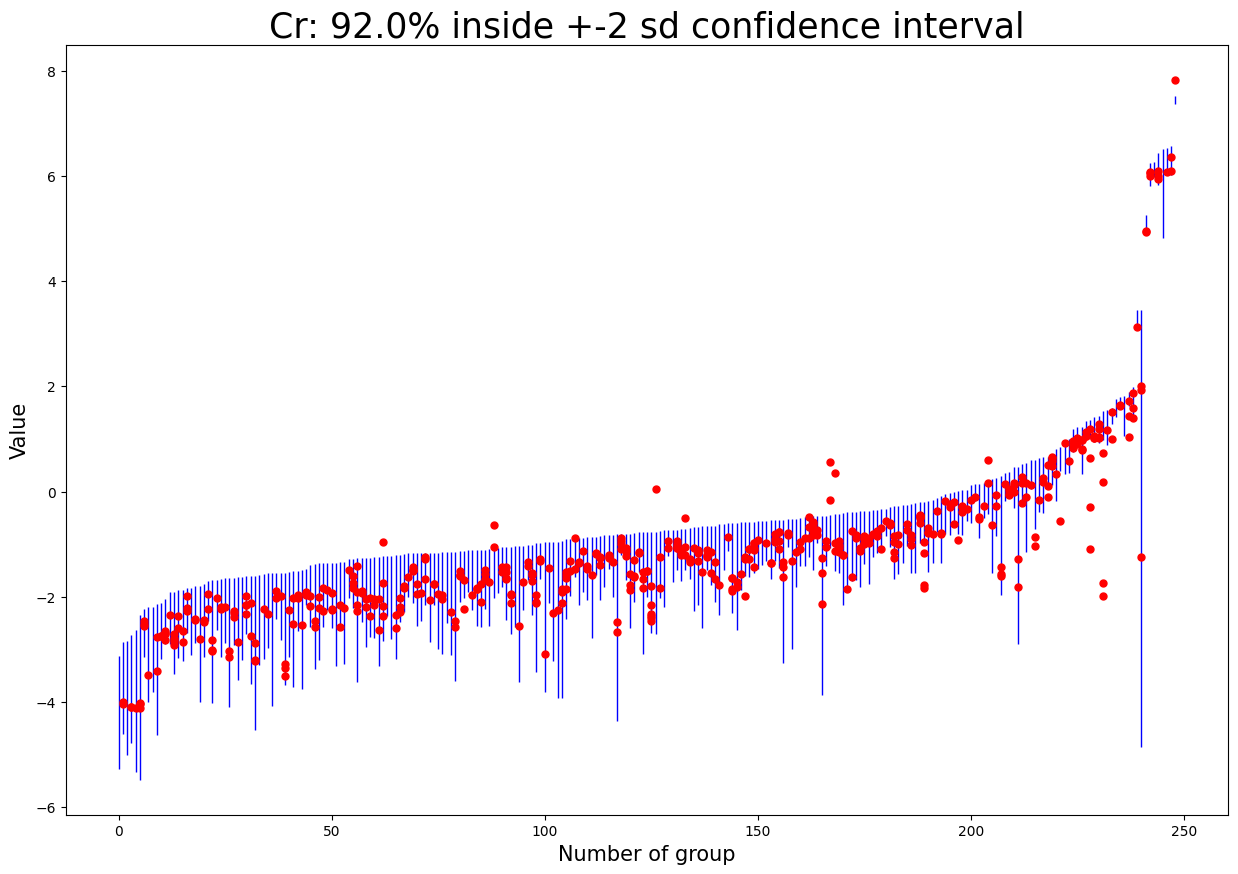

In [75]:
element = 2
percentage_correct = np.round(100*(np.array(sd_res_list).mean(0))[0,element], 1)

sorted_upper_bound_df = upper_bound_df.sort_values(upper_bound_df.columns[element])
sorted_upper_bound_df.reset_index(drop=True, inplace=True)
sorted_lower_bound_df = lower_bound_df.iloc[upper_bound_df.sort_values(upper_bound_df.columns[element]).index,:]
sorted_lower_bound_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_lower_bound_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_lower_bound_df.iloc[sample_id, element], 
                  ymax=sorted_upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
    
for row in range(outputs_df.shape[0]):
    new_index = sorted_upper_bound_df[sorted_upper_bound_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xlabel('Number of group',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside +-2 sd confidence interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
#plt.savefig('../figures/confidence_intervals_'+str(outputs_df.columns[element+1]))

### Visualisations of min-max intervals

In [76]:
# fig, ax = plt.subplots(2,4, figsize=(10,5))
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
#                   ymax=min_max_df.iloc[sample_id, element+1], 
#                   color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

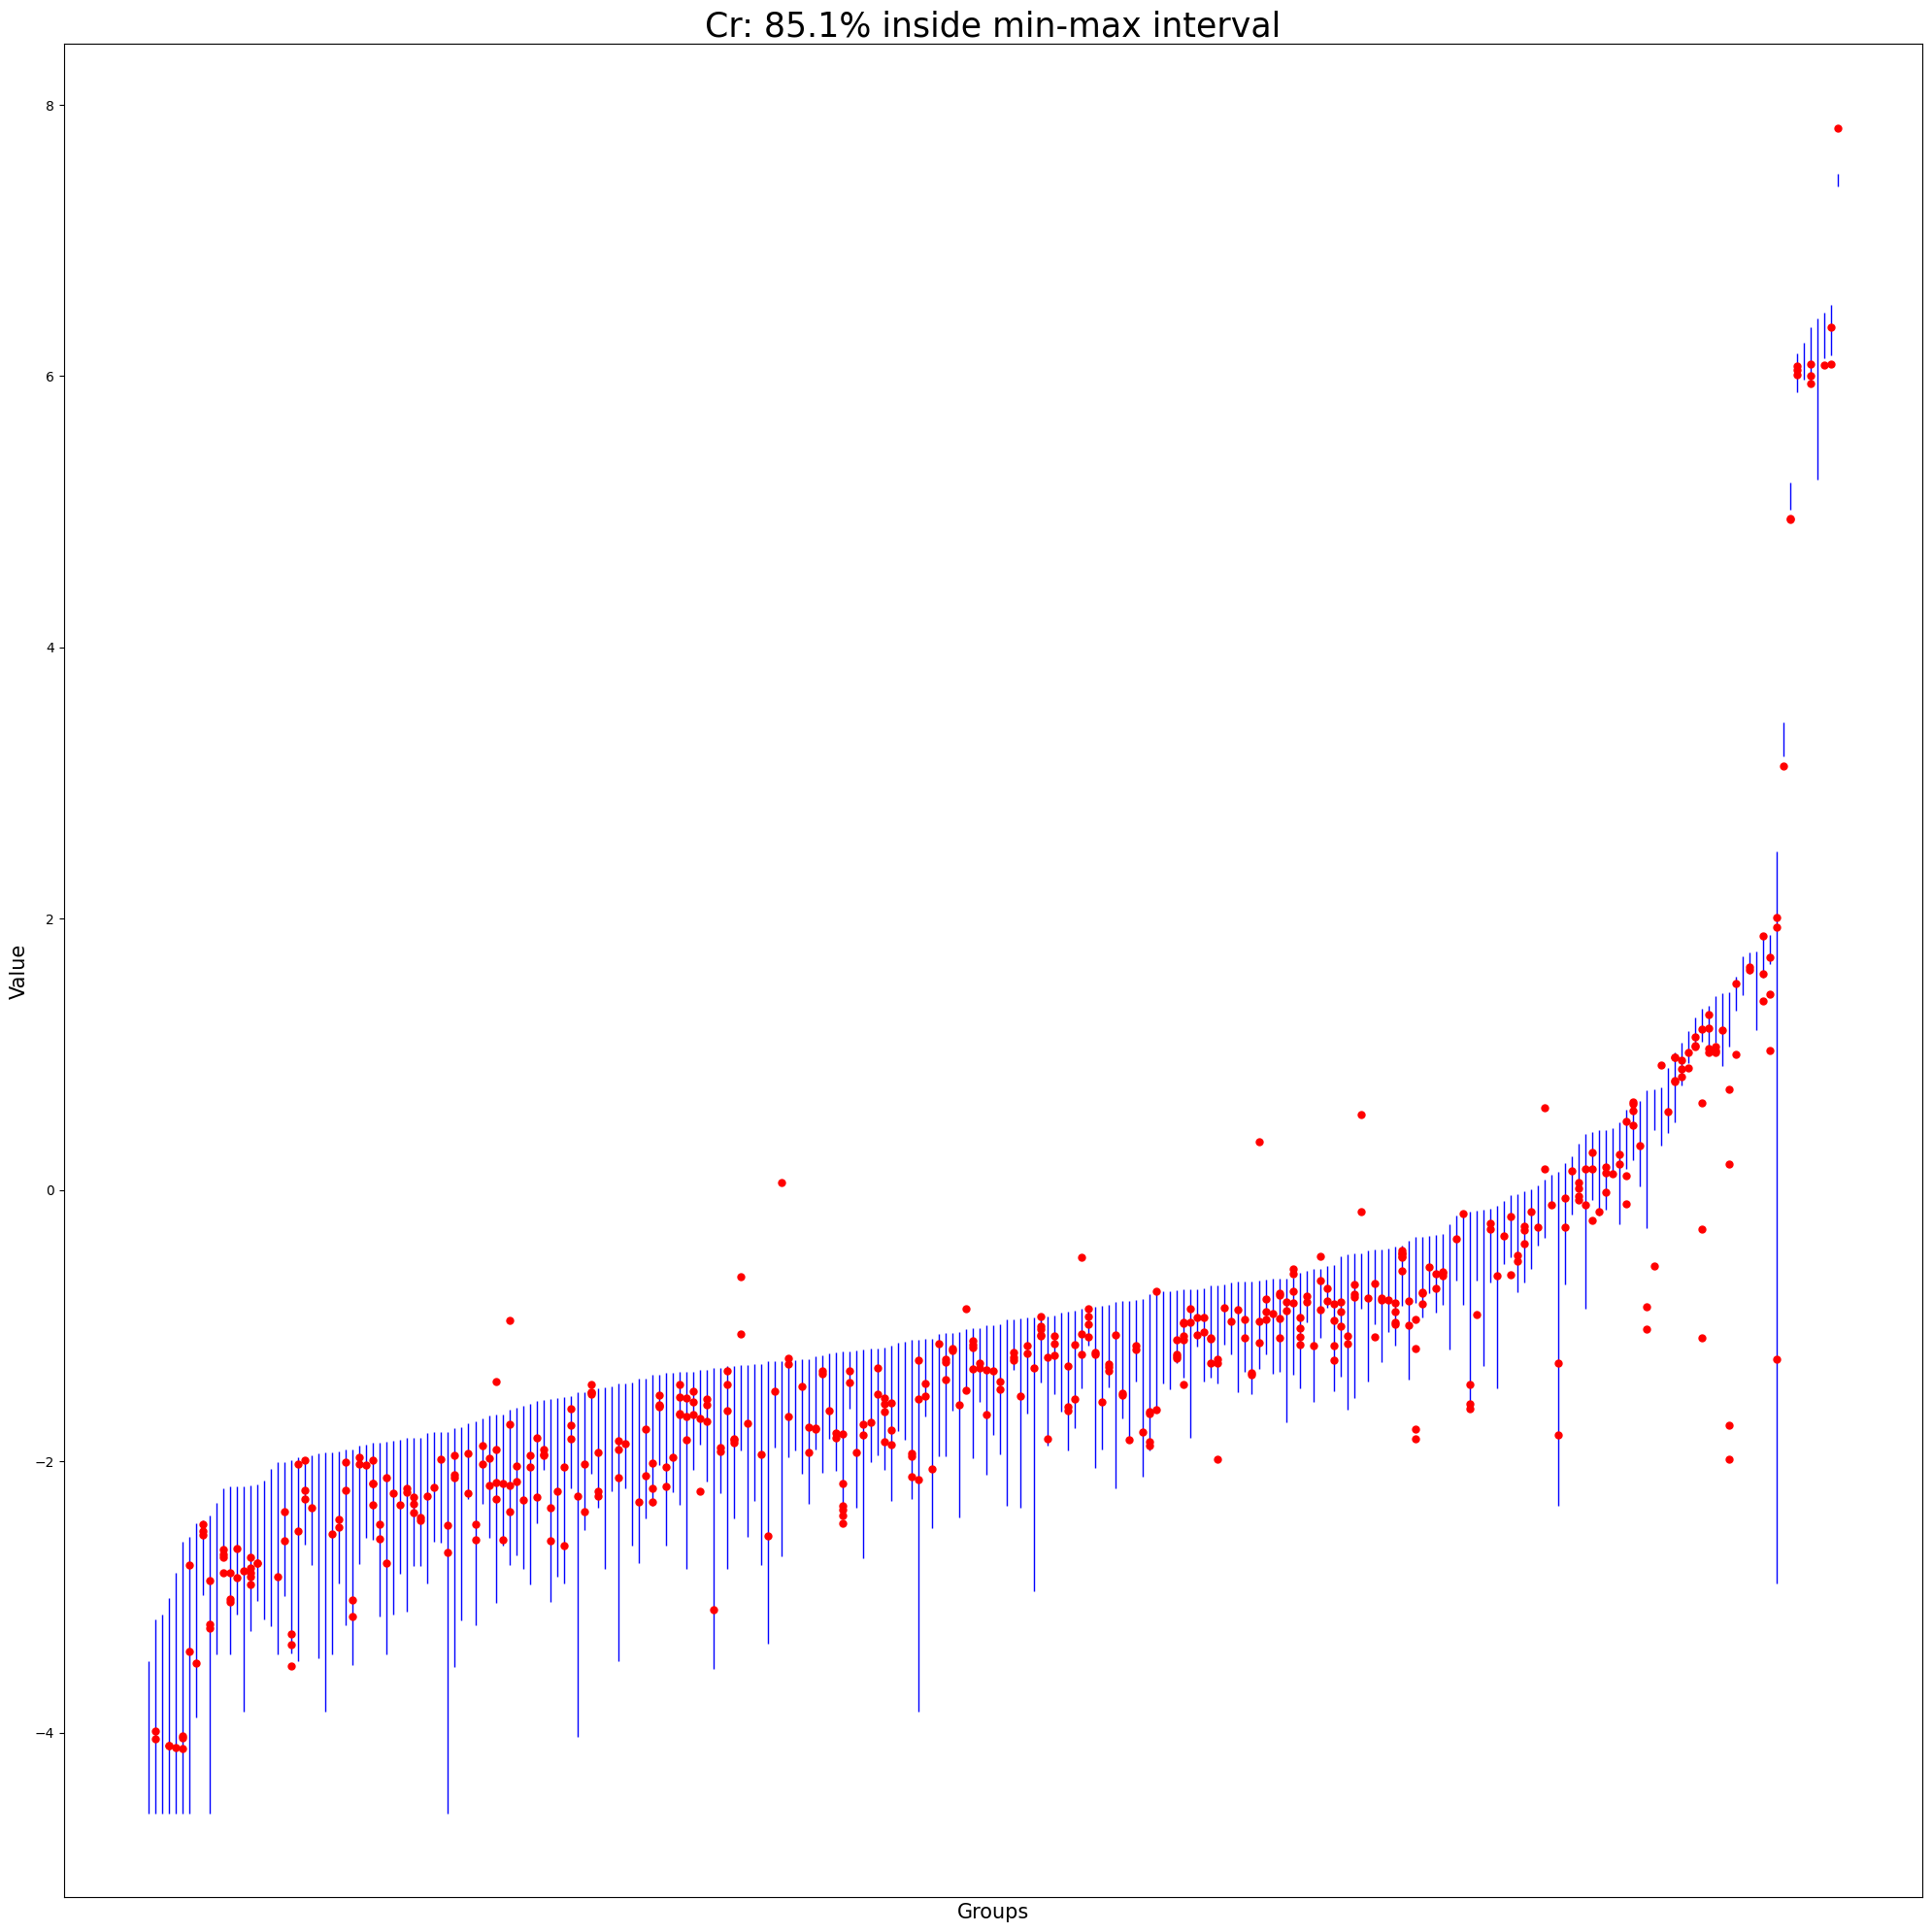

In [77]:
element = 2
percentage_correct = np.round(100*(np.array(min_max_res_list).mean(0))[0,element], 1)

sorted_min_max_df = min_max_df.sort_values(min_max_df.columns[element+1])
sorted_min_max_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_min_max_df.iloc[sample_id, element+len(elements_to_keep)+1], 
                  ymax=sorted_min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

for row in range(outputs_df.shape[0]):
    new_index = sorted_min_max_df[sorted_min_max_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xticks([], [])
plt.xlabel('Groups',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside min-max interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
plt.tight_layout()

#plt.savefig('../figures/min_max_intervals_'+str(outputs_df.columns[element+1]))

## Interpretability